In [1]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import numpy as np

X_test = np.load(r'/content/ModelingReady_X_test.npy', allow_pickle=True)

y_test = np.load(r'/content/ModelingReady_y_test.npy', allow_pickle=True)


In [3]:
import joblib
tokenizer = joblib.load('/content/input_tokenizer.pkl')

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_test =  pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=40,  # covers 99% of your data with minimal padding waste
    padding='post',
    truncating='post'
)

In [5]:

X_test

array([[   2,  247, 1497, ...,    0,    0,    0],
       [ 101,   86, 2703, ...,    0,    0,    0],
       [ 109,   54,   82, ...,    0,    0,    0],
       ...,
       [  30,   21,  354, ...,    0,    0,    0],
       [1256, 1284,  996, ...,    0,    0,    0],
       [  62,   12, 1911, ...,    0,    0,    0]], dtype=int32)

In [6]:
rnn = joblib.load(r'/content/RNN_baseline.pkl')
lstm = joblib.load(r'/content/Final_LSTM_Model.pkl')
gru = joblib.load(r'/content/Final_GRU_Model.pkl')
tf = joblib.load(r'/content/Transformer_encoder_final.pkl')
tf_ft = joblib.load(r'/content/Trasformer_fastetxt.pkl')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'Position_Embedding' (of type PositionEmbedding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# Classification Report

In [9]:
y_pred_r = rnn.predict(X_test).argmax(axis=1)
print(' The classification report of RNN')
print(classification_report(y_test, y_pred_r, target_names=['negative','neutral','positive']))

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
 The classification report of RNN
              precision    recall  f1-score   support

    negative       0.62      0.30      0.41       441
     neutral       0.83      0.91      0.86      1815
    positive       0.56      0.60      0.58       582

    accuracy                           0.75      2838
   macro avg       0.67      0.61      0.62      2838
weighted avg       0.74      0.75      0.74      2838



In [12]:
y_pred_l = lstm.predict(X_test).argmax(axis=1)
print(' The classification report of LSTM')
print(classification_report(y_test, y_pred_l, target_names=['negative','neutral','positive']))

89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step
 The classification report of LSTM
              precision    recall  f1-score   support

    negative       0.61      0.51      0.55       441
     neutral       0.86      0.90      0.88      1815
    positive       0.64      0.64      0.64       582

    accuracy                           0.78      2838
   macro avg       0.70      0.68      0.69      2838
weighted avg       0.78      0.78      0.78      2838



In [13]:
y_pred_g = gru.predict(X_test).argmax(axis=1)
print(' The classification report of GRU')
print(classification_report(y_test, y_pred_g, target_names=['negative','neutral','positive']))

89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
 The classification report of GRU
              precision    recall  f1-score   support

    negative       0.64      0.49      0.56       441
     neutral       0.84      0.93      0.89      1815
    positive       0.69      0.59      0.64       582

    accuracy                           0.79      2838
   macro avg       0.73      0.67      0.69      2838
weighted avg       0.78      0.79      0.78      2838



In [14]:
y_pred_t = tf.predict(X_test).argmax(axis=1)

print(' The classification report of Transformer encoder')
print(classification_report(y_test, y_pred_t, target_names=['negative','neutral','positive']))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'Position_Embedding' (of type PositionEmbedding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
 The classification report of Transformer encoder
              precision    recall  f1-score   support

    negative       0.70      0.68      0.69       441
     neutral       0.85      0.90      0.87      1815
    positive       0.76      0.63      0.69       582

    accuracy                           0.81      2838
   macro avg       0.77      0.73      0.75      2838
weighted avg       0.81      0.81      0.81      2838



In [10]:
y_pred_ft = tf_ft.predict(X_test).argmax(axis=1)

print(' The classification report of Transformer encoder (Fasttext)')
print(classification_report(y_test, y_pred_ft, target_names=['negative','neutral','positive']))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'Position_Embedding' (of type PositionEmbedding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step
 The classification report of Transformer encoder (Fasttext)
              precision    recall  f1-score   support

    negative       0.79      0.46      0.58       441
     neutral       0.78      0.97      0.87      1815
    positive       0.80      0.47      0.59       582

    accuracy                           0.79      2838
   macro avg       0.79      0.63      0.68      2838
weighted avg       0.79      0.79      0.77      2838



# Confusion matrix

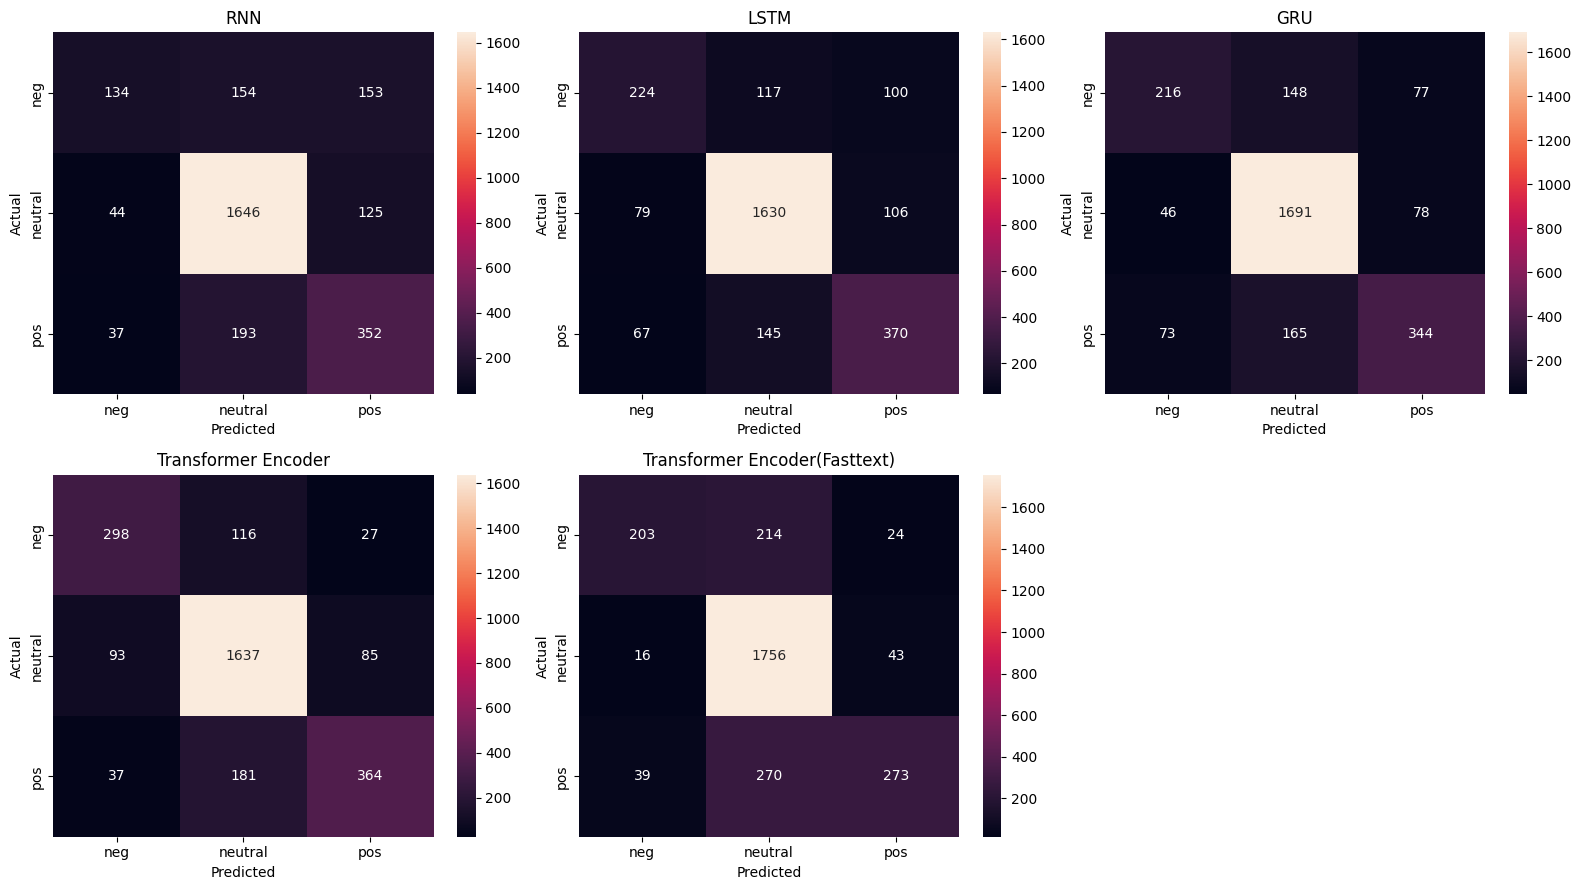

In [17]:
# lstm

m = [lstm,gru,tf]
y_pred = [y_pred_r, y_pred_l, y_pred_g, y_pred_t, y_pred_ft]
title = ['RNN','LSTM', 'GRU', "Transformer Encoder", "Transformer Encoder(Fasttext)"]

plt.figure(figsize = (16,9))
for i in [1,2,3,4,5]:
  plt.subplot(2,3,i)
  cm = confusion_matrix(y_test,y_pred[i-1])
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=['neg','neutral','pos'], yticklabels=['neg','neutral','pos'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(title[i-1])
  plt.tight_layout()


In [19]:
from sklearn.metrics import roc_auc_score

### Macro AUC (Macro-averaged ROC AUC)

**Definition:**
Macro AUC is the average of ROC AUC scores computed separately for each class in a multiclass classification problem, using a one-vs-rest approach.

**Steps:**
1. For each class `i`:
   - Treat class `i` as the positive class.
   - Treat all other classes as the negative class.
   - Compute ROC AUC for this binary setup.
2. Average the per-class AUCs:
   

\[
   \text{Macro AUC} = \frac{1}{K} \sum_{i=1}^{K} \text{AUC}(class_i \text{ vs rest})
   \]



**Key Point:**
- Each class contributes **equally**, regardless of its frequency.
- Highlights performance on minority classes.

**Example (3 classes: 1, 2, 3):**
- AUC(1 vs {2,3}) = 0.85  
- AUC(2 vs {1,3}) = 0.72  
- AUC(3 vs {1,2}) = 0.65  

Macro AUC = (0.85 + 0.72 + 0.65) / 3 = **0.74**


In [20]:
y_pred_proba = rnn.predict(X_test)  # softmax probabilities
auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print("RNN Macro AUC:", auc_macro)

y_pred_proba = lstm.predict(X_test)  # softmax probabilities
auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print("LSTM Macro AUC:", auc_macro)

y_pred_proba = gru.predict(X_test)  # softmax probabilities
auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print("GRU Macro AUC:", auc_macro)

y_pred_proba = tf.predict(X_test)  # softmax probabilities
auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print("Transformer Macro AUC:", auc_macro)

y_pred_proba = tf_ft.predict(X_test)  # softmax probabilities
auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print("Transformer(Fasttext) Macro AUC:", auc_macro)

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
RNN Macro AUC: 0.8513555916393257
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step
LSTM Macro AUC: 0.8769739770394892
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
GRU Macro AUC: 0.8816003097989548
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Transformer Macro AUC: 0.8971199054162251
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Transformer(Fasttext) Macro AUC: 0.8963606283530968


# Final result

In [21]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "RNN",
        "Val Accuracy": 0.744,       # best epoch (0), by val_loss
        "Val Loss": 0.612,
        "Test Accuracy": 0.75,
        "Precision (neg)": 0.62, "Recall (neg)": 0.30, "F1 (neg)": 0.41,
        "Precision (neutral)": 0.83, "Recall (neutral)": 0.91, "F1 (neutral)": 0.86,
        "Precision (pos)": 0.56, "Recall (pos)": 0.60, "F1 (pos)": 0.58,
        "Macro Precision": 0.67, "Macro Recall": 0.61, "Macro F1": 0.62,
        "Weighted F1": 0.74,
        "Macro AUC": 0.8514,
        "Time/Epoch (s)": 4,
    },
    {
        "Model": "LSTM",
        "Val Accuracy": 0.7922,
        "Val Loss": 0.594,
        "Test Accuracy": 0.78,
        "Precision (neg)": 0.61, "Recall (neg)": 0.51, "F1 (neg)": 0.55,
        "Precision (neutral)": 0.86, "Recall (neutral)": 0.90, "F1 (neutral)": 0.88,
        "Precision (pos)": 0.64, "Recall (pos)": 0.64, "F1 (pos)": 0.64,
        "Macro Precision": 0.70, "Macro Recall": 0.68, "Macro F1": 0.69,
        "Weighted F1": 0.78,
        "Macro AUC": 0.8770,
        "Time/Epoch (s)": 150,   # ~110-200s range, midpoint approx
    },
    {
        "Model": "GRU",
        "Val Accuracy": 0.7964,
        "Val Loss": 0.551,
        "Test Accuracy": 0.79,
        "Precision (neg)": 0.64, "Recall (neg)": 0.49, "F1 (neg)": 0.56,
        "Precision (neutral)": 0.84, "Recall (neutral)": 0.93, "F1 (neutral)": 0.89,
        "Precision (pos)": 0.69, "Recall (pos)": 0.59, "F1 (pos)": 0.64,
        "Macro Precision": 0.73, "Macro Recall": 0.67, "Macro F1": 0.69,
        "Weighted F1": 0.78,
        "Macro AUC": 0.8816,
        "Time/Epoch (s)": 115,   # ~90-140s range, midpoint approx
    },
    {
        "Model": "Transformer (Word2Vec)",
        "Val Accuracy": 0.8133,
        "Val Loss": 0.517,
        "Test Accuracy": 0.81,
        "Precision (neg)": 0.70, "Recall (neg)": 0.68, "F1 (neg)": 0.69,
        "Precision (neutral)": 0.85, "Recall (neutral)": 0.90, "F1 (neutral)": 0.87,
        "Precision (pos)": 0.76, "Recall (pos)": 0.63, "F1 (pos)": 0.69,
        "Macro Precision": 0.77, "Macro Recall": 0.73, "Macro F1": 0.75,
        "Weighted F1": 0.81,
        "Macro AUC": 0.8971,
        "Time/Epoch (s)": 13.5,
    },
    {
        "Model": "Transformer (FastText)",
        "Val Accuracy": 0.804,
        "Val Loss": 0.561,
        "Test Accuracy": 0.79,
        "Precision (neg)": 0.79, "Recall (neg)": 0.46, "F1 (neg)": 0.58,
        "Precision (neutral)": 0.78, "Recall (neutral)": 0.97, "F1 (neutral)": 0.87,
        "Precision (pos)": 0.80, "Recall (pos)": 0.47, "F1 (pos)": 0.59,
        "Macro Precision": 0.79, "Macro Recall": 0.63, "Macro F1": 0.68,
        "Weighted F1": 0.77,
        "Macro AUC": 0.8964,
        "Time/Epoch (s)": 13.5,
    },
])

results.set_index("Model", inplace=True)
results

,Val Accuracy,Val Loss,Test Accuracy,Precision (neg),Recall (neg),F1 (neg),Precision (neutral),Recall (neutral),F1 (neutral),Precision (pos),Recall (pos),F1 (pos),Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro AUC,Time/Epoch (s)
Model,,,,,,,,,,,,,,,,,,
RNN,0.7440,0.612,0.75,0.62,0.30,0.41,0.83,0.91,0.86,0.56,0.60,0.58,0.67,0.61,0.62,0.74,0.8514,4.0
LSTM,0.7922,0.594,0.78,0.61,0.51,0.55,0.86,0.90,0.88,0.64,0.64,0.64,0.70,0.68,0.69,0.78,0.8770,150.0
GRU,0.7964,0.551,0.79,0.64,0.49,0.56,0.84,0.93,0.89,0.69,0.59,0.64,0.73,0.67,0.69,0.78,0.8816,115.0
Transformer (Word2Vec),0.8133,0.517,0.81,0.70,0.68,0.69,0.85,0.90,0.87,0.76,0.63,0.69,0.77,0.73,0.75,0.81,0.8971,13.5
Transformer (FastText),0.8040,0.561,0.79,0.79,0.46,0.58,0.78,0.97,0.87,0.80,0.47,0.59,0.79,0.63,0.68,0.77,0.8964,13.5


In [32]:
results.to_csv("final_model_comparison.csv")

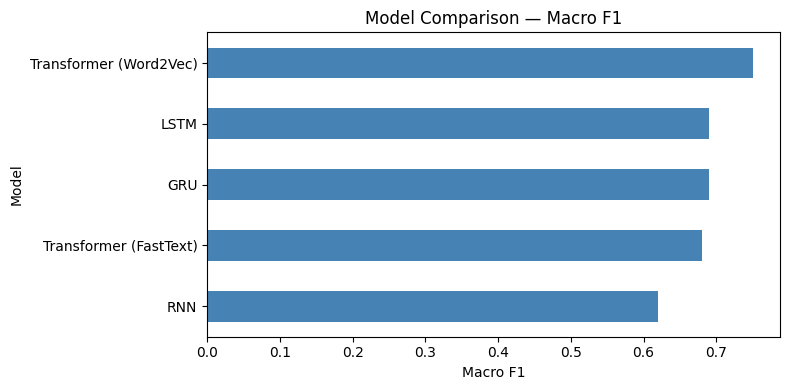

In [33]:
import matplotlib.pyplot as plt

results['Macro F1'].sort_values().plot(kind='barh', figsize=(8,4), color='steelblue')
plt.xlabel('Macro F1'); plt.title('Model Comparison — Macro F1')
plt.tight_layout()
plt.show()

In [34]:
sample_texts = ["Company beats earnings expectations", "Stock plummets after scandal", "Markets remain flat today"]
seq = pad_sequences(tokenizer.texts_to_sequences(sample_texts), maxlen=40, padding='post')
preds = tf.predict(seq)
for text, p in zip(sample_texts, preds):
    label = ['negative','neutral','positive'][p.argmax()]
    print(f"{text} → {label} ({p.max():.2f} confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Company beats earnings expectations → positive (0.55 confidence)
Stock plummets after scandal → negative (0.82 confidence)
Markets remain flat today → negative (0.55 confidence)
